In [7]:
!pip install -q datasets pandas matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

dataset = load_dataset("lacg030175/CIC-IoT-2023-neto-subsample", "random_3way", split="train[:10000]")
df = dataset.to_pandas()

print(f"Датасет успешно загружен. Размер: {df.shape}")
print("\nПервые 5 строк:")
display(df.head())

Датасет успешно загружен. Размер: (10000, 50)

Первые 5 строк:


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Number,Magnitue,Radius,Covariance,Variance,Weight,Label,Label_orig,attack_class,label
0,0.000000,741.859985,5.94,63.360001,185.031937,185.031937,0.0,0.0,0.0,0.0,...,9.5,43.611145,761.456787,305219.3125,0.95,141.550003,DDoS-ACK_Fragmentation,DDoS-ACK_Fragmentation,DDoS,1
1,5.319937,22640.099609,10.40,74.800003,41.719051,41.719051,0.0,0.0,0.0,0.0,...,13.5,34.210743,916.202209,420220.3750,1.00,244.600006,BenignTraffic,BenignTraffic,Benign,0
2,3.092224,272.600006,17.00,64.000000,0.491930,0.491930,0.0,0.0,0.0,0.0,...,5.5,13.711309,0.000000,0.0000,0.00,38.500000,DNS_Spoofing,DNS_Spoofing,Spoofing,1
3,8.375284,5683.399902,6.00,155.100006,35.487621,35.487621,0.0,0.0,0.0,0.0,...,13.5,30.803919,1167.457153,684978.8125,1.00,244.600006,MITM-ArpSpoofing,MITM-ArpSpoofing,Spoofing,1
4,0.088201,82134.500000,17.00,64.000000,610.776062,610.776062,0.0,0.0,0.0,0.0,...,9.5,41.680603,769.472107,311678.8125,0.95,141.550003,DDoS-UDP_Fragmentation,DDoS-UDP_Fragmentation,DDoS,1


КОЛИЧЕСТВО ТРАФИКА ПО КЛАССАМ
Attack (Атака): 8617 записей (86.2%)
Benign (Норма): 1383 записей (13.8%)
Всего записей: 10000


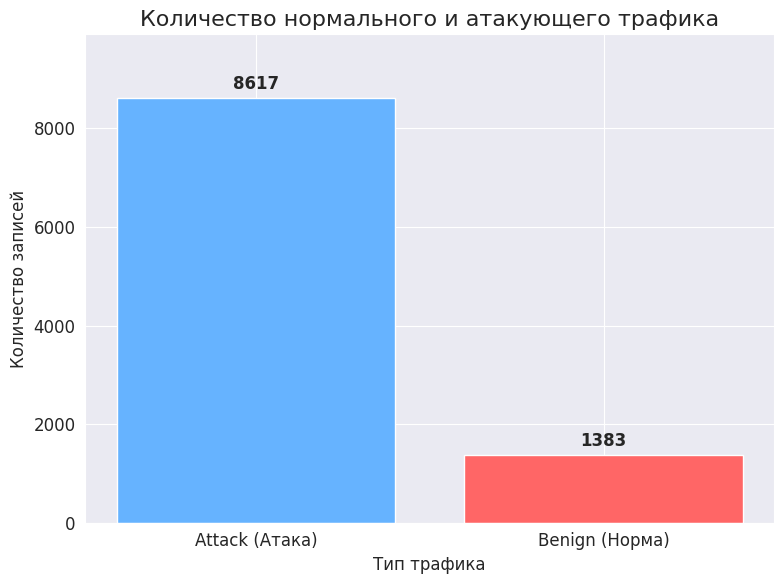


✅ График сохранен в traffic_count_bar.png


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

label_map = {0: 'Benign (Норма)', 1: 'Attack (Атака)'}
df['label_name'] = df['label'].map(label_map)

counts = df['label_name'].value_counts()
total = len(df)

print("=" * 50)
print("КОЛИЧЕСТВО ТРАФИКА ПО КЛАССАМ")
print("=" * 50)
for name, count in counts.items():
    percent = count / total * 100
    print(f"{name}: {count} записей ({percent:.1f}%)")
print(f"Всего записей: {total}")

plt.figure(figsize=(8, 6))
colors = ['#66b3ff', '#ff6666']
bars = plt.bar(counts.index, counts.values, color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + total*0.01,
             f'{int(height)}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Количество нормального и атакующего трафика', fontsize=16)
plt.xlabel('Тип трафика', fontsize=12)
plt.ylabel('Количество записей', fontsize=12)
plt.ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.savefig('traffic_count_bar.png', dpi=150)
plt.show()

МЕТРИКИ КЛАССИФИКАЦИИ
Accuracy : 0.9660
Precision: 0.9726
Recall   : 0.9884
F1-score : 0.9804
ROC-AUC  : 0.9895

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.83      0.87       277
           1       0.97      0.99      0.98      1723

    accuracy                           0.97      2000
   macro avg       0.95      0.91      0.93      2000
weighted avg       0.97      0.97      0.97      2000



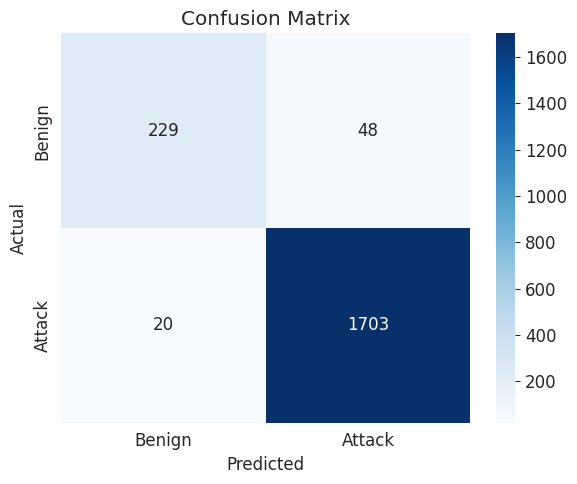

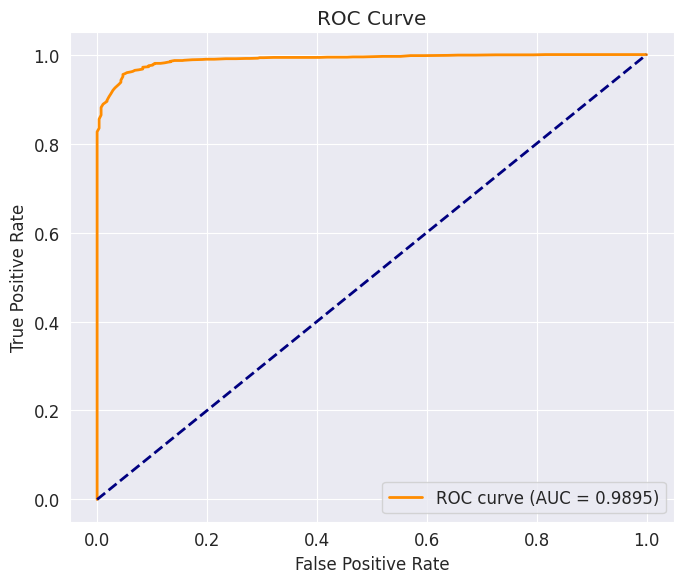

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])
X = numeric_df.drop(columns=['label'], errors='ignore').fillna(0)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # вероятность класса 1

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

print("=" * 50)
print("МЕТРИКИ КЛАССИФИКАЦИИ")
print("=" * 50)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

Топ-5 признаков:
1. rst_count: 0.1403
2. IAT: 0.1355
3. urg_count: 0.1028
4. Header_Length: 0.0765
5. flow_duration: 0.0750


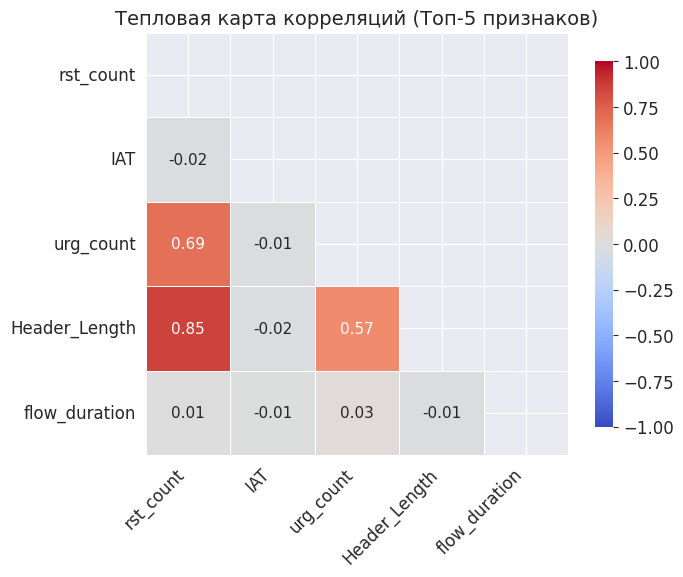

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=['label'], errors='ignore').select_dtypes(include=[np.number]).fillna(0)
y = df['label']

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
top_5 = importances.sort_values(ascending=False).head(5).index.tolist()

print("Топ-5 признаков:")
for i, feat in enumerate(top_5, 1):
    print(f"{i}. {feat}: {importances[feat]:.4f}")

plt.figure(figsize=(7, 6))
corr_top5 = df[top_5].corr()

mask = np.triu(np.ones_like(corr_top5, dtype=bool))

sns.heatmap(
    corr_top5,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 11}
)

plt.title('Тепловая карта корреляций (Топ-5 признаков)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('heatmap_top5.png', dpi=150)
plt.show()

=== MITRE ATT&CK Coverage ===
 attck_id                        attck_name  count
    T1498         Network Denial of Service   2819
    T1557           Adversary-in-the-Middle    674
    T1046         Network Service Discovery    370
    T1018           Remote System Discovery    331
    T1595                   Active Scanning    273
    T1185         Browser Session Hijacking     40
    T1059 Command and Scripting Interpreter     36
T1059.007                        JavaScript     27
    T1190 Exploit Public-Facing Application     13

Уникальных ATT&CK техник в датасете: 9


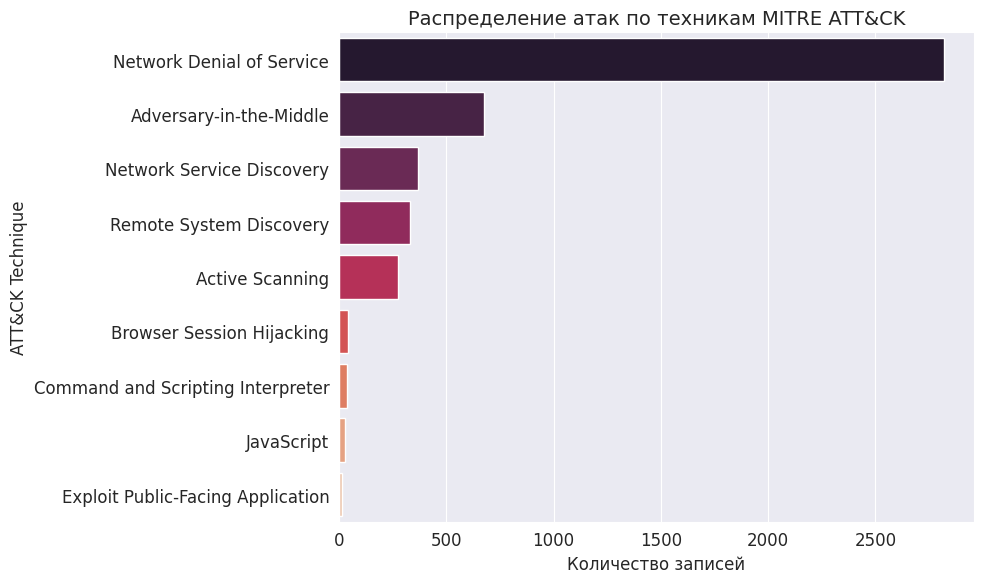

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ATTACK_MAPPING = {
    # DDoS
    "DDoS-ACK_Fragmentation":       ("T1498", "Network Denial of Service"),
    "DDoS-UDP_Fragmentation":       ("T1498", "Network Denial of Service"),
    "DDoS-SYN_Flood":               ("T1498", "Network Denial of Service"),
    "DDoS-TCP_Flood":               ("T1498", "Network Denial of Service"),
    "DDoS-HTTP_Flood":              ("T1498", "Network Denial of Service"),
    "DDoS-PSHACK_Fragmentation":    ("T1498", "Network Denial of Service"),
    "DDoS-ICMP_Flood":              ("T1498", "Network Denial of Service"),
    "DDoS-SlowLoris":               ("T1498", "Network Denial of Service"),
    # Spoofing
    "DNS_Spoofing":                 ("T1557", "Adversary-in-the-Middle"),
    "MITM-ArpSpoofing":             ("T1557", "Adversary-in-the-Middle"),
    # Brute force / Recon
    "Recon-PortScan":               ("T1046", "Network Service Discovery"),
    "VulnerabilityScan":            ("T1595", "Active Scanning"),
    "Recon-HostDiscovery":          ("T1018", "Remote System Discovery"),
    # Mirai / IoT malware
    "Mirai-greeth_flood":           ("T1498", "Network Denial of Service"),
    "Mirai-udpplain":               ("T1498", "Network Denial of Service"),
    # Web attacks
    "BrowserHijacking":             ("T1185", "Browser Session Hijacking"),
    "Uploading_Attack":             ("T1190", "Exploit Public-Facing Application"),
    "XSS":                          ("T1059.007", "JavaScript"),
    "SQL_injection":                ("T1190", "Exploit Public-Facing Application"),
    "CommandInjection":             ("T1059", "Command and Scripting Interpreter"),
    # Normal
    "BenignTraffic":                ("—", "Benign"),
}

df["attck_id"]     = df["Label_orig"].map(lambda x: ATTACK_MAPPING.get(x, ("—", "Unknown"))[0])
df["attck_name"]   = df["Label_orig"].map(lambda x: ATTACK_MAPPING.get(x, ("—", "Unknown"))[1])

attack_summary = (
    df[df["attck_id"] != "—"]
    .groupby(["attck_id", "attck_name"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("=== MITRE ATT&CK Coverage ===")
print(attack_summary.to_string(index=False))

unique_techniques = attack_summary["attck_id"].nunique()
print(f"\nУникальных ATT&CK техник в датасете: {unique_techniques}")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=attack_summary,
    y="attck_name",
    x="count",
    hue="attck_id",
    palette="rocket",
    legend=False
)
plt.title("Распределение атак по техникам MITRE ATT&CK", fontsize=14)
plt.xlabel("Количество записей")
plt.ylabel("ATT&CK Technique")
plt.tight_layout()
plt.savefig("attck_coverage.png", dpi=150)
plt.show()

attack_summary.to_csv("attck_coverage.csv", index=False)